<a href="https://colab.research.google.com/github/FatherNurt/FUNt-Cosmologiical-Model-of-All-Things/blob/main/FUNt_History_Plot_Against_h3pi_v0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FUNt History Plot Against h³π v0.1

**Purpose:** historical data comparison against the h³π transition-reference framework.  
**Status:** descriptive analysis only. No prediction performed.  
**Default adapter:** earthquake / USGS event adapter using the Venezuela event `us6000t7zp`.

This notebook replaces the old Fibonacci scaffold with a clearer historical framework:

```text
Observed history
    ↓
Perturbation history
    ↓
Transport history
    ↓
Accumulation history
    ↓
Transition strain history S(t)
    ↓
History plotted against h³π
    ↓
hHRT / hHRB state history
```

Important language rule:

> This notebook does **not** say h³π caused an event.  
> It says the observed history is plotted against the h³π reference framework.

Prediction logic belongs in a separate silo if it is ever justified.

In [ ]:
# ============================================================
# FUNt History Plot Against h3pi v0.1
# Historical / descriptive analysis only. No prediction performed.
# ============================================================

import requests
import json
import hashlib
import os
import zipfile
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

try:
    from IPython.display import display, Markdown
    HAS_IPYTHON = True
except Exception:
    HAS_IPYTHON = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

## 1. Configuration

Change only this block for a new historical run.

The engine is domain-neutral in language, but this v0.1 notebook includes an earthquake adapter for USGS event sequences.

In [ ]:
CONFIG = {
    "notebook_version": "FUNt History Plot Against h3pi v0.1",
    "analysis_name": "Earthquake History Plot Against h3pi",
    "domain": "earthquake",
    "adapter": "USGS Earthquake Event Adapter v0.1",
    "event_id": "us6000t7zp",  # Venezuela mainquake; replace with any USGS event ID
    "min_magnitude": 4.0,
    "max_radius_km": 500,
    "days_after_event_transition": 30,
    "hourly_bin_size_hours": 1,
    "rolling_window_hours": 6,
    "survival_windows_x": 3,
    "distance_bands_km": [0, 100, 250, 500],
    "source": "USGS FDSN Event API",
    "prediction_mode": False,
    "local_time_zone": "America/Caracas",
    "local_time_label": "Venezuela Time / VET",

    # h3pi reference layer
    "h3pi_operator": "h3pi",
    "h3pi_value": float(3 * np.pi),
    "h3pi_reference_mode": "history_plot_reference_only",

    # Transition-strain S parameters
    # These weights are research parameters, not claims of truth.
    "S_weights": {
        "perturbation": 0.40,
        "transport": 0.20,
        "accumulation": 0.25,
        "persistence": 0.15
    },
    "S_candidate_threshold_quantile": 0.90,
    "significant_aftershock_delta_mag": 3.0,
    "tau_HRT_hours": 3,
    "hHRB_requires_survival_windows": True,
    "small_catalog_warning_threshold": 10
}

CONFIG_JSON = json.dumps(CONFIG, sort_keys=True)
CONFIG_HASH = hashlib.sha256(CONFIG_JSON.encode("utf-8")).hexdigest()

print("==== Audit Header ====")
print(json.dumps(CONFIG, indent=2))
print("\nConfig SHA-256:", CONFIG_HASH)
print("Prediction mode:", CONFIG["prediction_mode"])

==== Audit Header ====
{
  "notebook_version": "FUNt History Plot Against h3pi v0.1",
  "analysis_name": "Earthquake History Plot Against h3pi",
  "domain": "earthquake",
  "adapter": "USGS Earthquake Event Adapter v0.1",
  "event_id": "us6000t7zp",
  "min_magnitude": 4.0,
  "max_radius_km": 500,
  "days_after_event_transition": 30,
  "hourly_bin_size_hours": 1,
  "rolling_window_hours": 6,
  "survival_windows_x": 3,
  "distance_bands_km": [
    0,
    100,
    250,
    500
  ],
  "source": "USGS FDSN Event API",
  "prediction_mode": false,
  "local_time_zone": "America/Caracas",
  "local_time_label": "Venezuela Time / VET",
  "h3pi_operator": "h3pi",
  "h3pi_value": 9.42477796076938,
  "h3pi_reference_mode": "history_plot_reference_only",
  "S_weights": {
    "perturbation": 0.4,
    "transport": 0.2,
    "accumulation": 0.25,
    "persistence": 0.15
  },
  "S_candidate_threshold_quantile": 0.9,
  "significant_aftershock_delta_mag": 3.0,
  "tau_HRT_hours": 3,
  "hHRB_requires_survival

## 2. Helper Functions

In [ ]:
def usgs_get_json(url, timeout=30):
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    return r.json()


def mag_to_energy_joules(m):
    # Gutenberg-Richter energy estimate: E = 10^(1.5M + 4.8) Joules.
    if pd.isna(m):
        return np.nan
    return 10 ** (1.5 * float(m) + 4.8)


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path


def save_json(path, obj):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=str)


def write_text(path, text):
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)


def normalize_01(series):
    s = pd.Series(series).astype(float)
    if len(s) == 0:
        return s
    s = s.replace([np.inf, -np.inf], np.nan).fillna(0)
    mn, mx = float(s.min()), float(s.max())
    if mx - mn <= 1e-12:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)


def classify_catalog_maturity(n):
    if n < 10:
        return "Preliminary"
    if n < 50:
        return "Developing"
    if n < 200:
        return "Moderate"
    if n < 1000:
        return "Mature"
    return "Research grade"


def format_duration(hours):
    total_minutes = int(round(hours * 60))
    days = total_minutes // (24 * 60)
    rem = total_minutes % (24 * 60)
    hrs = rem // 60
    mins = rem % 60
    return days, hrs, mins


def safe_idxmax(df, col):
    if df.empty or col not in df.columns or df[col].dropna().empty:
        return None
    return df[col].idxmax()


def state_to_code(state):
    mapping = {
        "quiet_history": 0,
        "perturbation_history": 1,
        "candidate_hHRT_history": 2,
        "persistent_hHRT_history": 3,
        "hHRB_history": 4,
        "relaxation_history": 5,
    }
    return mapping.get(state, -1)


def display_markdown(text):
    if HAS_IPYTHON:
        display(Markdown(text))
    else:
        print(text)

## 3. Event Transition Retrieval

The mainquake is the **Event Transition anchor** for this historical run.  
It is not called H=0 in this notebook.

In [ ]:
EVENT_ID = CONFIG["event_id"]
mainshock_url = "https://earthquake.usgs.gov/fdsnws/event/1/query?" + f"format=geojson&eventid={EVENT_ID}"

mainshock_geojson = usgs_get_json(mainshock_url)
main_props = mainshock_geojson["properties"]
main_coords = mainshock_geojson["geometry"]["coordinates"]

MAINQUAKE = {
    "event_id": EVENT_ID,
    "place": main_props.get("place"),
    "magnitude": main_props.get("mag"),
    "time_ms": main_props.get("time"),
    "time_utc": pd.to_datetime(main_props.get("time"), unit="ms", utc=True),
    "longitude": main_coords[0],
    "latitude": main_coords[1],
    "depth_km": main_coords[2],
    "url": main_props.get("url"),
}

MAINQUAKE["time_local"] = MAINQUAKE["time_utc"].tz_convert(CONFIG["local_time_zone"])

print("==== Mainquake / Event Transition Anchor ====")
for k, v in MAINQUAKE.items():
    print(f"{k}: {v}")

==== Mainquake / Event Transition Anchor ====
event_id: us6000t7zp
place: 28 km SE of Yumare, Venezuela
magnitude: 7.5
time_ms: 1782338711566
time_utc: 2026-06-24 22:05:11.566000+00:00
longitude: -68.4716
latitude: 10.4351
depth_km: 10
url: https://earthquake.usgs.gov/earthquakes/eventpage/us6000t7zp
time_local: 2026-06-24 18:05:11.566000-04:00


## 4. Create Run Folder

In [ ]:
RUN_SLUG = f"{CONFIG['domain']}_{EVENT_ID}_history_against_h3pi"
ROOT_DIR = ensure_dir("FUNt_History_Plot_Against_h3pi")
RUN_DIR = ensure_dir(os.path.join(ROOT_DIR, RUN_SLUG))
FIG_DIR = ensure_dir(os.path.join(RUN_DIR, "figures"))

save_json(os.path.join(RUN_DIR, "config.json"), CONFIG)
save_json(os.path.join(RUN_DIR, "event_transition.json"), MAINQUAKE)
write_text(os.path.join(RUN_DIR, "SHA256.txt"), CONFIG_HASH + "\n")

print("Run folder:", RUN_DIR)

Run folder: FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi


## 5. Earthquake Adapter — Historical Data Retrieval

The adapter converts USGS event history into domain-neutral quantities that the transition engine can use.

In [ ]:
main_time = MAINQUAKE["time_utc"]
end_time = main_time + pd.Timedelta(days=CONFIG["days_after_event_transition"])

starttime = main_time.strftime("%Y-%m-%dT%H:%M:%S")
endtime = end_time.strftime("%Y-%m-%dT%H:%M:%S")

query_url = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query?"
    f"format=geojson&starttime={starttime}&endtime={endtime}"
    f"&minmagnitude={CONFIG['min_magnitude']}"
    f"&latitude={MAINQUAKE['latitude']}&longitude={MAINQUAKE['longitude']}"
    f"&maxradiuskm={CONFIG['max_radius_km']}"
    "&orderby=time-asc"
)

retrieval_time_utc = datetime.now(timezone.utc)
retrieval_time_local = pd.Timestamp(retrieval_time_utc).tz_convert(CONFIG["local_time_zone"])

aftershock_geojson = usgs_get_json(query_url)
features = aftershock_geojson.get("features", [])

rows = []
rejected_mainquake = 0
rejected_before_transition = 0

for f in features:
    fid = f.get("id")
    p = f.get("properties", {})
    g = f.get("geometry", {}).get("coordinates", [np.nan, np.nan, np.nan])
    event_time = pd.to_datetime(p.get("time"), unit="ms", utc=True)

    if fid == EVENT_ID:
        rejected_mainquake += 1
        continue
    if event_time < main_time:
        rejected_before_transition += 1
        continue

    lon, lat, depth = g[0], g[1], g[2]
    distance_km = haversine_km(MAINQUAKE["latitude"], MAINQUAKE["longitude"], lat, lon)
    hours_since = (event_time - main_time).total_seconds() / 3600.0
    mag = p.get("mag")

    rows.append({
        "event_id": fid,
        "time_utc": event_time,
        "time_local": event_time.tz_convert(CONFIG["local_time_zone"]),
        "hours_since_event_transition": hours_since,
        "magnitude": mag,
        "energy_J": mag_to_energy_joules(mag),
        "place": p.get("place"),
        "latitude": lat,
        "longitude": lon,
        "depth_km": depth,
        "distance_km": distance_km,
        "usgs_url": p.get("url")
    })

df_events = pd.DataFrame(rows)

if not df_events.empty:
    df_events = df_events.sort_values("time_utc").reset_index(drop=True)
    df_events["cumulative_energy_J"] = df_events["energy_J"].cumsum()
    df_events["cumulative_event_count"] = np.arange(1, len(df_events) + 1)
    df_events["hour_bin"] = np.floor(df_events["hours_since_event_transition"]).astype(int)

catalog_maturity = classify_catalog_maturity(len(df_events))
small_catalog_warning = len(df_events) < CONFIG["small_catalog_warning_threshold"]

print("==== Data Acquisition Audit ====")
print("USGS query:", query_url)
print("Retrieval UTC:", retrieval_time_utc.isoformat())
print("Retrieval local:", retrieval_time_local.strftime("%Y-%m-%d %I:%M:%S %p %z"))
print("Raw events retrieved:", len(features))
print("Rejected as mainquake:", rejected_mainquake)
print("Rejected before transition:", rejected_before_transition)
print("Aftershocks analyzed:", len(df_events))
print("Catalog maturity:", catalog_maturity)
if small_catalog_warning:
    print("Small-catalog warning: diagnostics are observational only and not statistically meaningful.")

df_events.head()

==== Data Acquisition Audit ====
USGS query: https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2026-06-24T22:05:11&endtime=2026-07-24T22:05:11&minmagnitude=4.0&latitude=10.4351&longitude=-68.4716&maxradiuskm=500&orderby=time-asc
Retrieval UTC: 2026-06-27T00:42:52.591771+00:00
Retrieval local: 2026-06-26 08:42:52 PM -0400
Raw events retrieved: 5
Rejected as mainquake: 1
Rejected before transition: 0
Aftershocks analyzed: 4
Catalog maturity: Preliminary
Small-catalog warning: diagnostics are observational only and not statistically meaningful.


,event_id,time_utc,time_local,hours_since_event_transition,magnitude,energy_J,place,latitude,longitude,depth_km,distance_km,usgs_url,cumulative_energy_J,cumulative_event_count,hour_bin
0,us6000t80d,2026-06-24 22:23:54.046000+00:00,2026-06-24 18:23:54.046000-04:00,0.311800,4.5,3.548134e+11,"13 km N of Caucagüito, Venezuela",10.6092,-66.7168,10,192.817940,https://earthquake.usgs.gov/earthquakes/eventp...,3.548134e+11,1,0
1,us6000t81p,2026-06-25 05:48:23.136000+00:00,2026-06-25 01:48:23.136000-04:00,7.719881,4.4,2.511886e+11,"5 km NE of Guatire, Venezuela",10.5111,-66.5057,10,215.122326,https://earthquake.usgs.gov/earthquakes/eventp...,6.060020e+11,2,7
2,us6000t8d1,2026-06-26 04:19:30.378000+00:00,2026-06-26 00:19:30.378000-04:00,30.238559,4.4,2.511886e+11,"17 km WSW of Morón, Venezuela",10.4537,-68.3607,10,12.302315,https://earthquake.usgs.gov/earthquakes/eventp...,8.571907e+11,3,30
3,us6000t8k6,2026-06-26 22:16:11.931000+00:00,2026-06-26 18:16:11.931000-04:00,48.183435,4.7,7.079458e+11,"54 km N of El Limón, Venezuela",10.8000,-67.5993,10,103.609954,https://earthquake.usgs.gov/earthquakes/eventp...,1.565136e+12,4,48


## 6. SITREP — Human-Readable First

This is the first thing a student or operator should read. No arithmetic required.

In [ ]:
sequence_age_hours = (pd.Timestamp(retrieval_time_utc) - main_time).total_seconds() / 3600.0
seq_days, seq_hrs, seq_mins = format_duration(sequence_age_hours)

last_sig = None
if not df_events.empty:
    idx = safe_idxmax(df_events, "time_utc")
    if idx is not None:
        last_sig = df_events.loc[idx]

largest_evt = None
if not df_events.empty:
    idx = safe_idxmax(df_events, "energy_J")
    if idx is not None:
        largest_evt = df_events.loc[idx]

sitrep_lines = []
sitrep_lines.append("# FUNt SITREP")
sitrep_lines.append("")
sitrep_lines.append(f"**Analysis:** {CONFIG['analysis_name']}")
sitrep_lines.append(f"**Domain:** {CONFIG['domain']}")
sitrep_lines.append(f"**Location:** {MAINQUAKE['place']}")
sitrep_lines.append(f"**Event Transition:** M{MAINQUAKE['magnitude']} at {MAINQUAKE['time_local'].strftime('%Y-%m-%d %I:%M:%S %p %z')}")
sitrep_lines.append("")
sitrep_lines.append("## Current sequence age")
sitrep_lines.append(f"**{seq_days} days, {seq_hrs} hours, {seq_mins} minutes**")
sitrep_lines.append(f"({sequence_age_hours:.2f} hours since Event Transition)")
sitrep_lines.append("")
sitrep_lines.append("## Catalog status")
sitrep_lines.append(f"**{catalog_maturity}** — {len(df_events)} qualifying aftershocks")
if small_catalog_warning:
    sitrep_lines.append("Small catalog: diagnostics are observational only, not statistically meaningful.")
sitrep_lines.append("")
if largest_evt is not None:
    time_since_largest = sequence_age_hours - float(largest_evt['hours_since_event_transition'])
    d, h, m = format_duration(max(time_since_largest, 0))
    sitrep_lines.append("## Largest observed aftershock in this history")
    sitrep_lines.append(f"**M{largest_evt['magnitude']:.1f}** at {largest_evt['time_local'].strftime('%Y-%m-%d %I:%M:%S %p %z')}")
    sitrep_lines.append(f"Occurred {largest_evt['hours_since_event_transition']:.2f} hours after Event Transition.")
    sitrep_lines.append(f"Time since largest observed aftershock at runtime: {d} days, {h} hours, {m} minutes.")
    sitrep_lines.append("")
sitrep_lines.append("## Prediction")
sitrep_lines.append("**None.** This is a historical plot against h³π, not a forecast.")
sitrep_lines.append("")
sitrep_text = "\n".join(sitrep_lines)
display_markdown(sitrep_text)
write_text(os.path.join(RUN_DIR, "SITREP.md"), sitrep_text)

# FUNt SITREP

**Analysis:** Earthquake History Plot Against h3pi
**Domain:** earthquake
**Location:** 28 km SE of Yumare, Venezuela
**Event Transition:** M7.5 at 2026-06-24 06:05:11 PM -0400

## Current sequence age
**2 days, 2 hours, 38 minutes**
(50.63 hours since Event Transition)

## Catalog status
**Preliminary** — 4 qualifying aftershocks
Small catalog: diagnostics are observational only, not statistically meaningful.

## Largest observed aftershock in this history
**M4.7** at 2026-06-26 06:16:11 PM -0400
Occurred 48.18 hours after Event Transition.
Time since largest observed aftershock at runtime: 0 days, 2 hours, 27 minutes.

## Prediction
**None.** This is a historical plot against h³π, not a forecast.


## 7. Historical Ledgers

The event ledger and hourly history are the raw material for the transition engine.

In [ ]:
transition_csv = os.path.join(RUN_DIR, "observed_history_ledger.csv")
df_events.to_csv(transition_csv, index=False)

if df_events.empty:
    df_hourly = pd.DataFrame()
else:
    max_hour = max(int(np.ceil(df_events["hours_since_event_transition"].max())), int(np.ceil(sequence_age_hours)))
    full_hours = pd.DataFrame({"hour": np.arange(0, max_hour + 1)})

    grouped = (
        df_events.groupby("hour_bin")
        .agg(
            event_count=("event_id", "count"),
            energy_J=("energy_J", "sum"),
            max_magnitude=("magnitude", "max"),
            mean_magnitude=("magnitude", "mean"),
            mean_depth_km=("depth_km", "mean"),
            mean_distance_km=("distance_km", "mean")
        )
        .rename_axis("hour")
        .reset_index()
    )

    df_hourly = full_hours.merge(grouped, on="hour", how="left")
    df_hourly["event_count"] = df_hourly["event_count"].fillna(0)
    df_hourly["energy_J"] = df_hourly["energy_J"].fillna(0)
    df_hourly["cumulative_energy_J"] = df_hourly["energy_J"].cumsum()
    df_hourly["cumulative_event_count"] = df_hourly["event_count"].cumsum()

    x = CONFIG["survival_windows_x"]
    df_hourly["active_window"] = df_hourly["event_count"] > 0
    df_hourly["survival_x_windows"] = df_hourly["active_window"].rolling(x, min_periods=x).sum() >= x

hourly_csv = os.path.join(RUN_DIR, "hourly_history_ledger.csv")
df_hourly.to_csv(hourly_csv, index=False)

print("Saved:", transition_csv)
print("Saved:", hourly_csv)
df_hourly.head(12)

Saved: FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/observed_history_ledger.csv
Saved: FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/hourly_history_ledger.csv


,hour,event_count,energy_J,max_magnitude,mean_magnitude,mean_depth_km,mean_distance_km,cumulative_energy_J,cumulative_event_count,active_window,survival_x_windows
0,0,1.0,3.548134e+11,4.5,4.5,10.0,192.817940,3.548134e+11,1.0,True,False
1,1,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,1.0,False,False
2,2,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,1.0,False,False
3,3,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,1.0,False,False
4,4,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,1.0,False,False
5,5,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,1.0,False,False
6,6,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,1.0,False,False
7,7,1.0,2.511886e+11,4.4,4.4,10.0,215.122326,6.060020e+11,2.0,True,False
8,8,0.0,0.000000e+00,NaN,NaN,NaN,NaN,6.060020e+11,2.0,False,False
9,9,0.0,0.000000e+00,NaN,NaN,NaN,NaN,6.060020e+11,2.0,False,False


## 8. Domain-Neutral Transition Engine Core

The adapter has produced historical data.  
The engine computes operator histories and transition strain **S(t)**.

Current v0.1 earthquake mapping:

- **Perturbation history:** normalized hourly energy release
- **Transport history:** normalized distance/depth movement, when present
- **Accumulation history:** normalized cumulative energy
- **Persistence history:** recent survival across active windows

These are research mappings, not final laws.

In [ ]:
if df_hourly.empty:
    df_engine = pd.DataFrame()
else:
    df_engine = df_hourly.copy()

    # Perturbation: how much energy was released in this hour?
    df_engine["perturbation_history"] = normalize_01(np.log10(df_engine["energy_J"] + 1))

    # Accumulation: how much total energy has accumulated historically?
    df_engine["accumulation_history"] = normalize_01(np.log10(df_engine["cumulative_energy_J"] + 1))

    # Persistence: how much activity survived the configured rolling window?
    window = CONFIG["survival_windows_x"]
    df_engine["persistence_history"] = (
        df_engine["active_window"].astype(float).rolling(window, min_periods=1).mean()
    )

    # Transport: spatial movement proxy from mean distance and depth variation.
    # Missing hours are set to zero because there was no observed event in that hour.
    distance_component = normalize_01(df_engine["mean_distance_km"].fillna(0))
    depth_component = normalize_01(df_engine["mean_depth_km"].fillna(0))
    df_engine["transport_history"] = normalize_01(0.7 * distance_component + 0.3 * depth_component)

    weights = CONFIG["S_weights"]
    df_engine["S_transition_strain"] = (
        weights["perturbation"] * df_engine["perturbation_history"] +
        weights["transport"] * df_engine["transport_history"] +
        weights["accumulation"] * df_engine["accumulation_history"] +
        weights["persistence"] * df_engine["persistence_history"]
    )

    df_engine["dS_dt"] = df_engine["S_transition_strain"].diff().fillna(0)
    df_engine["d2S_dt2"] = df_engine["dS_dt"].diff().fillna(0)

    # h3pi reference: not causation, not prediction. Pure historical reference layer.
    h3pi = CONFIG["h3pi_value"]
    df_engine["S_against_h3pi"] = df_engine["S_transition_strain"] / h3pi
    df_engine["dS_dt_against_h3pi"] = df_engine["dS_dt"] / h3pi

    # Candidate transition is derived from S, not assumed from h3pi.
    if len(df_engine) > 0:
        threshold = float(df_engine["S_transition_strain"].quantile(CONFIG["S_candidate_threshold_quantile"]))
    else:
        threshold = np.nan
    df_engine["candidate_transition_history"] = df_engine["S_transition_strain"] >= threshold

    # hHRT and hHRB are states, not operators.
    tau = CONFIG["tau_HRT_hours"]
    df_engine["hHRT_state_history"] = False
    for idx, row in df_engine[df_engine["candidate_transition_history"]].iterrows():
        h0 = int(row["hour"])
        mask = (df_engine["hour"] >= h0) & (df_engine["hour"] <= h0 + tau)
        df_engine.loc[mask, "hHRT_state_history"] = True

    df_engine["hHRB_state_history"] = (
        df_engine["hHRT_state_history"] & df_engine["survival_x_windows"].astype(bool)
    )

    # Plain-language phase history.
    states = []
    for _, r in df_engine.iterrows():
        if bool(r["hHRB_state_history"]):
            states.append("hHRB_history")
        elif bool(r["hHRT_state_history"]):
            states.append("candidate_hHRT_history")
        elif r["S_transition_strain"] > 0 and r["dS_dt"] < 0:
            states.append("relaxation_history")
        elif r["perturbation_history"] > 0:
            states.append("perturbation_history")
        else:
            states.append("quiet_history")
    df_engine["state_history"] = states
    df_engine["state_code"] = df_engine["state_history"].apply(state_to_code)

engine_csv = os.path.join(RUN_DIR, "history_against_h3pi_engine_ledger.csv")
df_engine.to_csv(engine_csv, index=False)
print("Saved:", engine_csv)
df_engine.head(15)

Saved: FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/history_against_h3pi_engine_ledger.csv


,hour,event_count,energy_J,max_magnitude,mean_magnitude,mean_depth_km,mean_distance_km,cumulative_energy_J,cumulative_event_count,active_window,survival_x_windows,perturbation_history,accumulation_history,persistence_history,transport_history,S_transition_strain,dS_dt,d2S_dt2,S_against_h3pi,dS_dt_against_h3pi,candidate_transition_history,hHRT_state_history,hHRB_state_history,state_history,state_code
0,0,1.0,3.548134e+11,4.5,4.5,10.0,192.817940,3.548134e+11,1.0,True,False,0.974684,0.000000,1.000000,0.927422,0.725358,0.000000,0.000000,0.076963,0.000000,True,True,False,candidate_hHRT_history,2
1,1,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,1.0,False,False,0.000000,0.000000,0.500000,0.000000,0.075000,-0.650358,-0.650358,0.007958,-0.069005,False,True,False,candidate_hHRT_history,2
2,2,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,1.0,False,False,0.000000,0.000000,0.333333,0.000000,0.050000,-0.025000,0.625358,0.005305,-0.002653,False,True,False,candidate_hHRT_history,2
3,3,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,1.0,False,False,0.000000,0.000000,0.000000,0.000000,0.000000,-0.050000,-0.025000,0.000000,-0.005305,False,True,False,candidate_hHRT_history,2
4,4,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,1.0,False,False,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.050000,0.000000,0.000000,False,False,False,quiet_history,0
5,5,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,1.0,False,False,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,False,quiet_history,0
6,6,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,1.0,False,False,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,False,quiet_history,0
7,7,1.0,2.511886e+11,4.4,4.4,10.0,215.122326,6.060020e+11,2.0,True,False,0.962025,0.360675,0.333333,1.000000,0.724979,0.724979,0.724979,0.076923,0.076923,True,True,False,candidate_hHRT_history,2
8,8,0.0,0.000000e+00,NaN,NaN,NaN,NaN,6.060020e+11,2.0,False,False,0.000000,0.360675,0.333333,0.000000,0.140169,-0.584810,-1.309789,0.014872,-0.062050,False,True,False,candidate_hHRT_history,2
9,9,0.0,0.000000e+00,NaN,NaN,NaN,NaN,6.060020e+11,2.0,False,False,0.000000,0.360675,0.333333,0.000000,0.140169,0.000000,0.584810,0.014872,0.000000,False,True,False,candidate_hHRT_history,2


## 9. History Plot Against h³π Diagnostics

These diagnostics are historical observations only.

In [ ]:
if df_engine.empty:
    diagnostics = {"status": "No data available for engine diagnostics."}
else:
    idx_max_S = safe_idxmax(df_engine, "S_transition_strain")
    idx_max_dS = safe_idxmax(df_engine, "dS_dt")
    idx_max_energy = safe_idxmax(df_engine, "energy_J")

    candidate_hours = df_engine.loc[df_engine["candidate_transition_history"], "hour"].astype(int).tolist()

    diagnostics = {
        "analysis_name": CONFIG["analysis_name"],
        "catalog_maturity": catalog_maturity,
        "small_catalog_warning": small_catalog_warning,
        "aftershocks_analyzed": int(len(df_events)),
        "sequence_age_hours_at_runtime": float(sequence_age_hours),
        "sequence_age_days_at_runtime": float(sequence_age_hours / 24),
        "S_candidate_threshold_quantile": CONFIG["S_candidate_threshold_quantile"],
        "S_candidate_threshold_value": float(df_engine["S_transition_strain"].quantile(CONFIG["S_candidate_threshold_quantile"])),
        "candidate_transition_hours_observed": candidate_hours,
        "max_S_hour": int(df_engine.loc[idx_max_S, "hour"]) if idx_max_S is not None else None,
        "max_S_value": float(df_engine.loc[idx_max_S, "S_transition_strain"]) if idx_max_S is not None else None,
        "max_S_against_h3pi": float(df_engine.loc[idx_max_S, "S_against_h3pi"]) if idx_max_S is not None else None,
        "max_dS_dt_hour": int(df_engine.loc[idx_max_dS, "hour"]) if idx_max_dS is not None else None,
        "max_dS_dt_value": float(df_engine.loc[idx_max_dS, "dS_dt"]) if idx_max_dS is not None else None,
        "max_hourly_energy_hour": int(df_engine.loc[idx_max_energy, "hour"]) if idx_max_energy is not None else None,
        "max_hourly_energy_J": float(df_engine.loc[idx_max_energy, "energy_J"]) if idx_max_energy is not None else None,
        "hHRT_active_hours": int(df_engine["hHRT_state_history"].sum()),
        "hHRB_active_hours": int(df_engine["hHRB_state_history"].sum()),
        "prediction_performed": CONFIG["prediction_mode"],
        "interpretation_guardrail": "Observed candidate transition is not a predicted future event. This notebook plots history against h3pi only."
    }

save_json(os.path.join(RUN_DIR, "diagnostics.json"), diagnostics)
print("==== History Plot Against h3pi Diagnostics ====")
for k, v in diagnostics.items():
    print(f"{k}: {v}")

==== History Plot Against h3pi Diagnostics ====
analysis_name: Earthquake History Plot Against h3pi
catalog_maturity: Preliminary
aftershocks_analyzed: 4
sequence_age_hours_at_runtime: 50.62806271416666
sequence_age_days_at_runtime: 2.1095026130902776
S_candidate_threshold_quantile: 0.9
S_candidate_threshold_value: 0.29499999999999993
candidate_transition_hours_observed: [0, 7, 30, 48, 49, 50]
max_S_hour: 48
max_S_value: 0.8274285830717178
max_S_against_h3pi: 0.08779289936759123
max_dS_dt_hour: 7
max_dS_dt_value: 0.7249789591583242
max_hourly_energy_hour: 48
max_hourly_energy_J: 707945784384.1403
hHRT_active_hours: 16
hHRB_active_hours: 0
prediction_performed: False
interpretation_guardrail: Observed candidate transition is not a predicted future event. This notebook plots history against h3pi only.


## 10. Figures

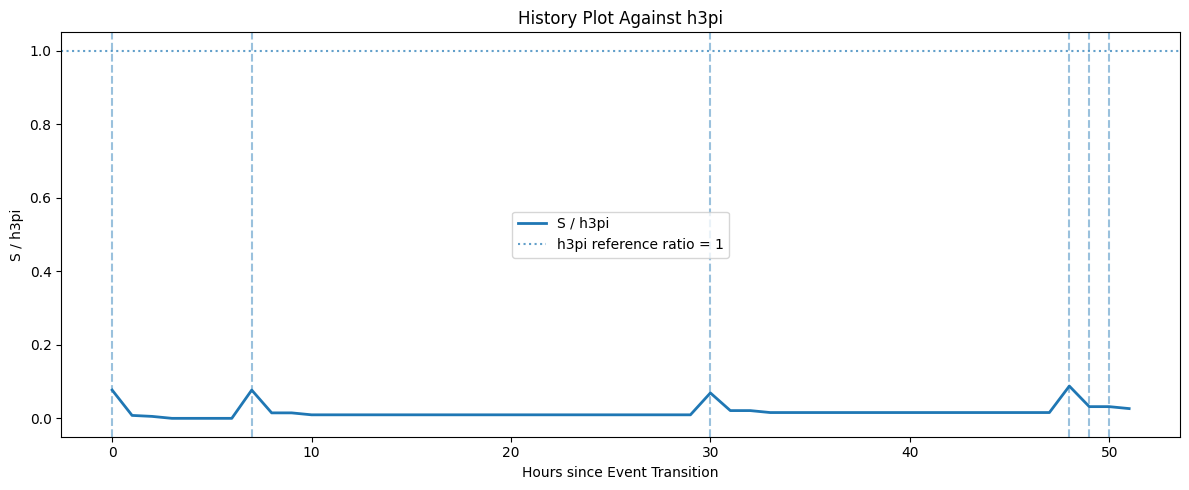

Saved: FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/history_plot_against_h3pi.png


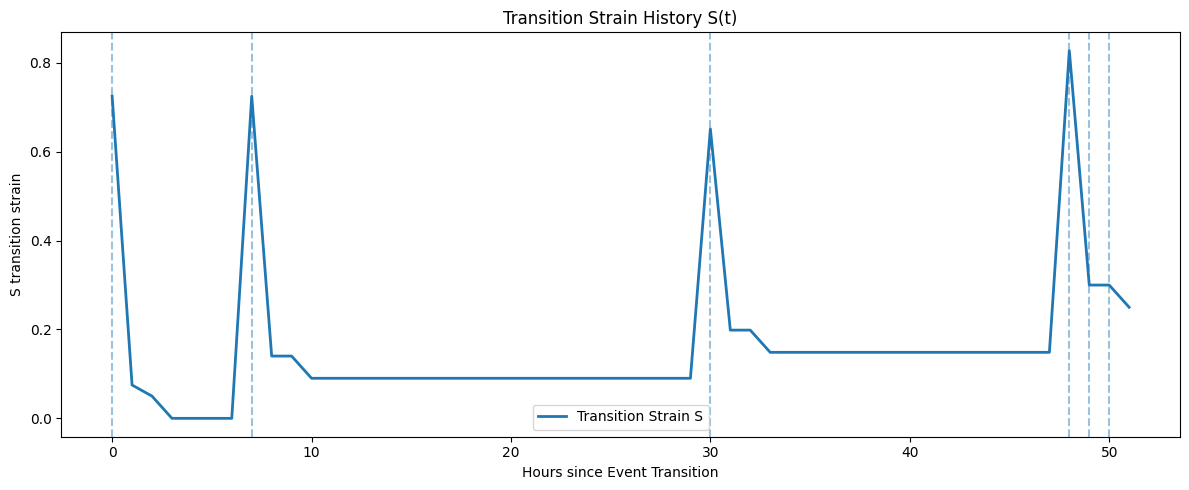

Saved: FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/transition_strain_history_S.png


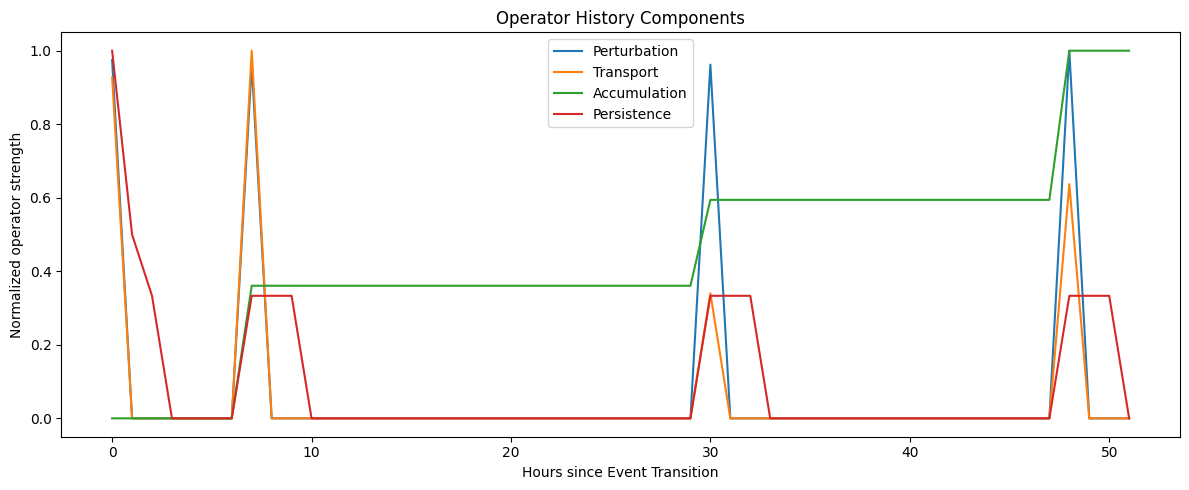

Saved: FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/operator_history_components.png


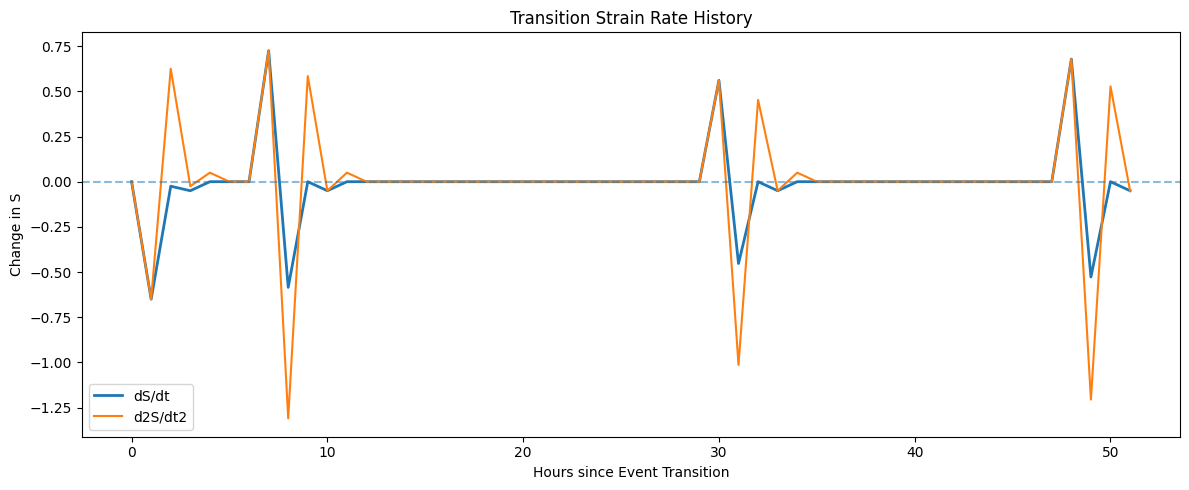

Saved: FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/transition_strain_rate_history.png


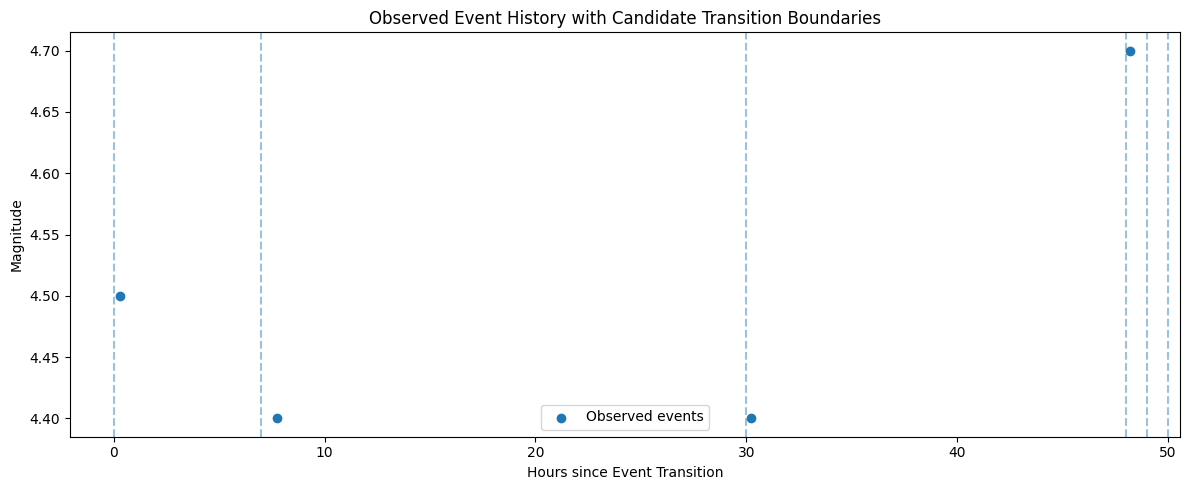

Saved: FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/observed_event_history.png


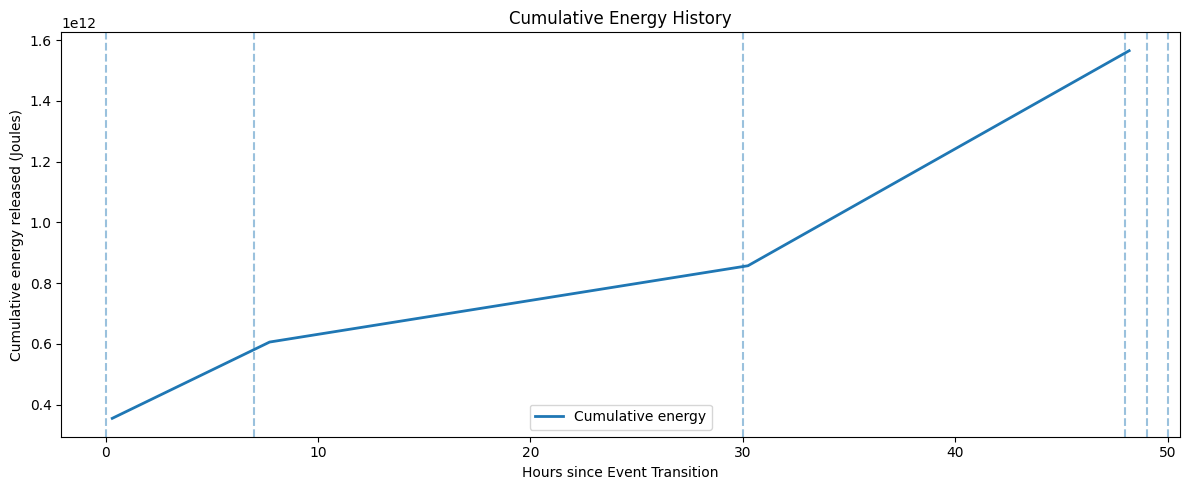

Saved: FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/cumulative_energy_history.png


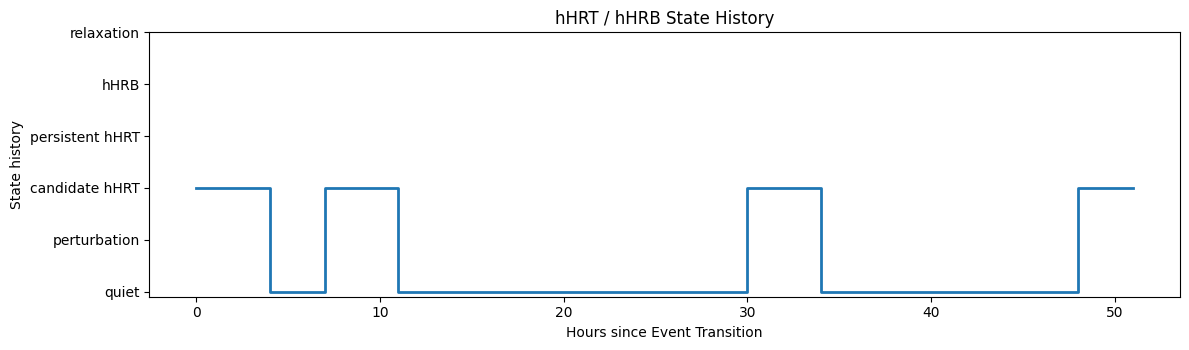

Saved: FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/hHRT_hHRB_state_history.png


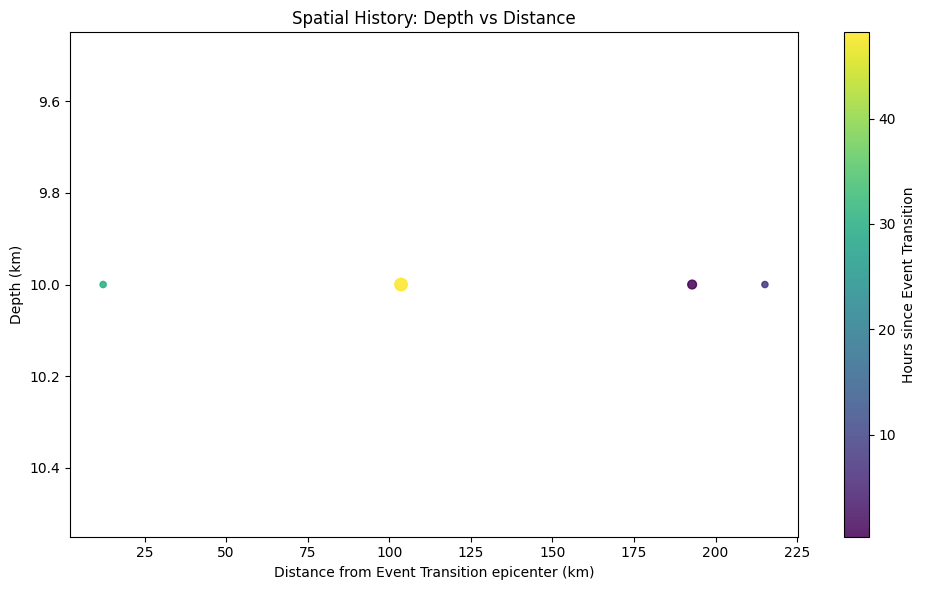

Saved: FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/spatial_history_depth_distance.png
{
  "figure_count": 8,
  "figures": [
    "FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/history_plot_against_h3pi.png",
    "FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/transition_strain_history_S.png",
    "FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/operator_history_components.png",
    "FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/transition_strain_rate_history.png",
    "FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/observed_event_history.png",
    "FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/cumulative_energy_history.png",
    "FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/figures/hHRT_hHRB_state_history.png",
 

In [ ]:
def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()
    print("Saved:", path)
    return path

figure_paths = []

if df_engine.empty:
    print("No figures generated because no historical data was returned.")
else:
    candidate_hours = df_engine.loc[df_engine["candidate_transition_history"], "hour"].astype(int).tolist()

    # Figure 1: SITREP-style visual timeline: S against h3pi reference ratio
    plt.figure(figsize=(12, 5))
    plt.plot(df_engine["hour"], df_engine["S_against_h3pi"], linewidth=2, label="S / h3pi")
    for h in candidate_hours:
        plt.axvline(h, linestyle="--", alpha=0.45)
    plt.axhline(1.0, linestyle=":", alpha=0.7, label="h3pi reference ratio = 1")
    plt.xlabel("Hours since Event Transition")
    plt.ylabel("S / h3pi")
    plt.title("History Plot Against h3pi")
    plt.legend()
    figure_paths.append(savefig("history_plot_against_h3pi.png"))

    # Figure 2: S(t)
    plt.figure(figsize=(12, 5))
    plt.plot(df_engine["hour"], df_engine["S_transition_strain"], linewidth=2, label="Transition Strain S")
    for h in candidate_hours:
        plt.axvline(h, linestyle="--", alpha=0.45)
    plt.xlabel("Hours since Event Transition")
    plt.ylabel("S transition strain")
    plt.title("Transition Strain History S(t)")
    plt.legend()
    figure_paths.append(savefig("transition_strain_history_S.png"))

    # Figure 3: Operator histories
    plt.figure(figsize=(12, 5))
    plt.plot(df_engine["hour"], df_engine["perturbation_history"], label="Perturbation")
    plt.plot(df_engine["hour"], df_engine["transport_history"], label="Transport")
    plt.plot(df_engine["hour"], df_engine["accumulation_history"], label="Accumulation")
    plt.plot(df_engine["hour"], df_engine["persistence_history"], label="Persistence")
    plt.xlabel("Hours since Event Transition")
    plt.ylabel("Normalized operator strength")
    plt.title("Operator History Components")
    plt.legend()
    figure_paths.append(savefig("operator_history_components.png"))

    # Figure 4: dS and acceleration
    plt.figure(figsize=(12, 5))
    plt.plot(df_engine["hour"], df_engine["dS_dt"], linewidth=2, label="dS/dt")
    plt.plot(df_engine["hour"], df_engine["d2S_dt2"], linewidth=1.5, label="d2S/dt2")
    plt.axhline(0, linestyle="--", alpha=0.5)
    plt.xlabel("Hours since Event Transition")
    plt.ylabel("Change in S")
    plt.title("Transition Strain Rate History")
    plt.legend()
    figure_paths.append(savefig("transition_strain_rate_history.png"))

    # Figure 5: observed events and energy
    if not df_events.empty:
        plt.figure(figsize=(12, 5))
        plt.scatter(df_events["hours_since_event_transition"], df_events["magnitude"], label="Observed events")
        for h in candidate_hours:
            plt.axvline(h, linestyle="--", alpha=0.45)
        plt.xlabel("Hours since Event Transition")
        plt.ylabel("Magnitude")
        plt.title("Observed Event History with Candidate Transition Boundaries")
        plt.legend()
        figure_paths.append(savefig("observed_event_history.png"))

        plt.figure(figsize=(12, 5))
        plt.plot(df_events["hours_since_event_transition"], df_events["cumulative_energy_J"], linewidth=2, label="Cumulative energy")
        for h in candidate_hours:
            plt.axvline(h, linestyle="--", alpha=0.45)
        plt.xlabel("Hours since Event Transition")
        plt.ylabel("Cumulative energy released (Joules)")
        plt.title("Cumulative Energy History")
        plt.legend()
        figure_paths.append(savefig("cumulative_energy_history.png"))

    # Figure 6: phase / state history
    plt.figure(figsize=(12, 3.6))
    plt.step(df_engine["hour"], df_engine["state_code"], where="post", linewidth=2)
    plt.yticks(
        [0, 1, 2, 3, 4, 5],
        ["quiet", "perturbation", "candidate hHRT", "persistent hHRT", "hHRB", "relaxation"]
    )
    plt.xlabel("Hours since Event Transition")
    plt.ylabel("State history")
    plt.title("hHRT / hHRB State History")
    figure_paths.append(savefig("hHRT_hHRB_state_history.png"))

    # Figure 7: spatial bubble if events exist
    if not df_events.empty:
        plt.figure(figsize=(10, 6))
        sizes = 20 + 60 * normalize_01(df_events["magnitude"])
        sc = plt.scatter(
            df_events["distance_km"],
            df_events["depth_km"],
            s=sizes,
            c=df_events["hours_since_event_transition"],
            alpha=0.85
        )
        plt.gca().invert_yaxis()
        plt.xlabel("Distance from Event Transition epicenter (km)")
        plt.ylabel("Depth (km)")
        plt.title("Spatial History: Depth vs Distance")
        plt.colorbar(sc, label="Hours since Event Transition")
        figure_paths.append(savefig("spatial_history_depth_distance.png"))

figure_audit = {"figure_count": len(figure_paths), "figures": figure_paths}
save_json(os.path.join(RUN_DIR, "figure_audit.json"), figure_audit)
print(json.dumps(figure_audit, indent=2))

## 11. Human-Readable Report

In [ ]:
summary_lines = []
summary_lines.append("FUNt History Plot Against h3pi v0.1")
summary_lines.append("Historical / descriptive analysis only. No prediction performed.")
summary_lines.append("")
summary_lines.append("==== Mainquake / Event Transition ====")
for k, v in MAINQUAKE.items():
    summary_lines.append(f"{k}: {v}")
summary_lines.append("")
summary_lines.append("==== SITREP ====")
summary_lines.append(sitrep_text.replace("# ", "").replace("## ", ""))
summary_lines.append("")
summary_lines.append("==== Configuration ====")
summary_lines.append(json.dumps(CONFIG, indent=2))
summary_lines.append(f"Config SHA-256: {CONFIG_HASH}")
summary_lines.append("")
summary_lines.append("==== Data Acquisition ====")
summary_lines.append(f"USGS query: {query_url}")
summary_lines.append(f"Retrieval UTC: {retrieval_time_utc.isoformat()}")
summary_lines.append(f"Retrieval local: {retrieval_time_local.strftime('%Y-%m-%d %I:%M:%S %p %z')}")
summary_lines.append(f"Raw events retrieved: {len(features)}")
summary_lines.append(f"Rejected as mainquake: {rejected_mainquake}")
summary_lines.append(f"Rejected before transition: {rejected_before_transition}")
summary_lines.append(f"Aftershocks analyzed: {len(df_events)}")
summary_lines.append(f"Catalog maturity: {catalog_maturity}")
summary_lines.append(f"Small-catalog warning: {small_catalog_warning}")
summary_lines.append("")
summary_lines.append("==== History Plot Against h3pi Diagnostics ====")
for k, v in diagnostics.items():
    summary_lines.append(f"{k}: {v}")
summary_lines.append("")
summary_lines.append("==== Figures ====")
for p in figure_paths:
    summary_lines.append(p)
summary_lines.append("")
summary_lines.append("==== Audit Footer ====")
summary_lines.append(f"Notebook Version: {CONFIG['notebook_version']}")
summary_lines.append(f"Analysis: {CONFIG['analysis_name']}")
summary_lines.append(f"Event ID: {EVENT_ID}")
summary_lines.append(f"Prediction performed: {CONFIG['prediction_mode']}")
summary_lines.append("NO PREDICTION PERFORMED. This notebook plots observed history against h3pi only.")
summary_lines.append("Observed candidate transition != predicted future event.")

summary_txt = os.path.join(RUN_DIR, "summary_report.txt")
write_text(summary_txt, "\n".join(summary_lines))
print("Saved:", summary_txt)
print("\n".join(summary_lines[:90]))

Saved: FUNt_History_Plot_Against_h3pi/earthquake_us6000t7zp_history_against_h3pi/summary_report.txt
FUNt History Plot Against h3pi v0.1
Historical / descriptive analysis only. No prediction performed.

==== Mainquake / Event Transition ====
event_id: us6000t7zp
place: 28 km SE of Yumare, Venezuela
magnitude: 7.5
time_ms: 1782338711566
time_utc: 2026-06-24 22:05:11.566000+00:00
longitude: -68.4716
latitude: 10.4351
depth_km: 10
url: https://earthquake.usgs.gov/earthquakes/eventpage/us6000t7zp
time_local: 2026-06-24 18:05:11.566000-04:00

==== SITREP ====
FUNt SITREP

**Analysis:** Earthquake History Plot Against h3pi
**Domain:** earthquake
**Location:** 28 km SE of Yumare, Venezuela
**Event Transition:** M7.5 at 2026-06-24 06:05:11 PM -0400

#Current sequence age
**2 days, 2 hours, 38 minutes**
(50.63 hours since Event Transition)

#Catalog status
**Preliminary** — 4 qualifying aftershocks
Small catalog: diagnostics are observational only, not statistically meaningful.

#Largest observe

## 12. Zip Run Folder

In [ ]:
zip_path = f"{RUN_SLUG}_FUNt_History_Plot_Against_h3pi_v0_1.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files_in_dir in os.walk(RUN_DIR):
        for filename in files_in_dir:
            full_path = os.path.join(root, filename)
            arcname = os.path.relpath(full_path, ROOT_DIR)
            z.write(full_path, arcname)

print("Saved zip:", zip_path)

if IN_COLAB:
    files.download(zip_path)

Saved zip: earthquake_us6000t7zp_history_against_h3pi_FUNt_History_Plot_Against_h3pi_v0_1.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Audit Footer

This notebook produces a historical **History Plot Against h³π**.

**No prediction is performed.**

Candidate transition markers are historical classifications derived from observed data already present in the catalog. They are not future-event predictions.